In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


### DATA Preprocessing

# 1. Handling Missing Values 


In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# 2. Feature Engineering

In [9]:
#1. Age

df["Age"] = 2026-df["Year_Birth"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
#2. Customer Joining Date(No. of days)

df["Dt_Customer"] =  pd.to_datetime(df["Dt_Customer"] , dayfirst = True)

In [12]:
refrence_date = df["Dt_Customer"].max()

In [13]:
df["Customer_Tenure_days"] = (refrence_date - df["Dt_Customer"]).dt.days

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [15]:
#3. Total Spending

df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]


In [16]:
#4. Total Kids

df["Total_kids"] = df["Kidhome"] + df["Teenhome"]

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_kids
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [18]:
# Education values three category assign to make our feature look simpler (So that algo better perform)

df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
df["Education"] = df["Education"].replace({

       "Basic" : "UnderGraduate" , "2n Cycle" : "UnderGraduate",
       "Graduation"    : "Graduate",
       "Master" : "PostGraduate" , "PhD" : "PostGraduate"            

    
})

In [20]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [21]:
# Marital_Status values two category assign to make our feature look simpler (So that algo better perform)

df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [22]:
df["Living_with"] = df["Marital_Status"].replace({

    "Married" : "Partner" , "Together" : "Partner",
    "Single" : "Alone" , "Divorced" : "Alone" , "Widow" : "Alone",
    "Absurd" : "Alone" , "YOLO" : "Alone"
    
})

In [23]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_kids,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


# 3. Drop Features

In [25]:
cols = ["ID" , "Year_Birth" , "Marital_Status" , "Kidhome" , "Teenhome" , "Dt_Customer" ]
spending = ["MntWines" , "MntFruits" , "MntMeatProducts" , "MntFishProducts" , "MntSweetProducts" , "MntGoldProds"]

In [26]:
cols_spending = cols + spending

In [27]:
cols_spending

['ID',
 'Year_Birth',
 'Marital_Status',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds']

In [28]:
df.shape

(2240, 27)

In [29]:
#df_clean.shape

In [30]:
df_clean = df.drop(columns = cols_spending)

In [31]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_days', 'Total_spending',
       'Total_kids', 'Living_with'],
      dtype='object')

In [32]:
df_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_kids,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [33]:
df_clean.shape

(2240, 15)

In [34]:
df.shape

(2240, 27)

<Axes: xlabel='Income', ylabel='Total_spending'>

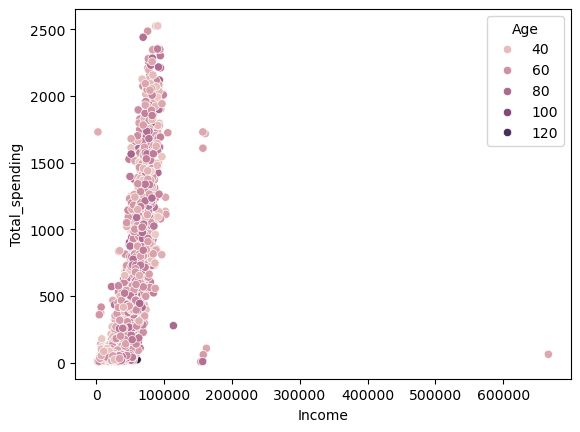

In [35]:
# 4/08/2026

sns.scatterplot(x = df_clean["Income"] , y = df_clean["Total_spending"] , hue= df_clean["Age"])

<Axes: xlabel='Income', ylabel='Total_spending'>

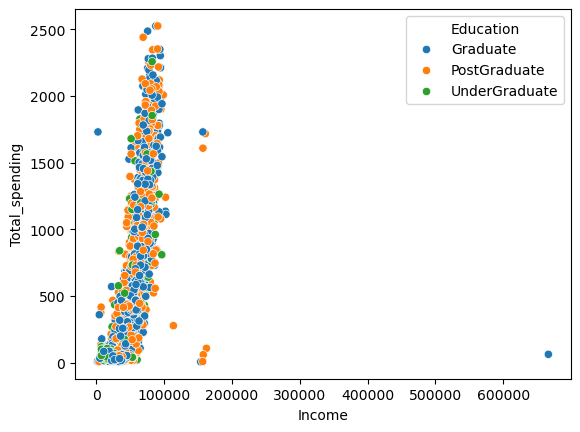

In [36]:
sns.scatterplot(x = df_clean["Income"] , y = df_clean["Total_spending"] , hue= df_clean["Education"])

<Axes: xlabel='Income', ylabel='Total_spending'>

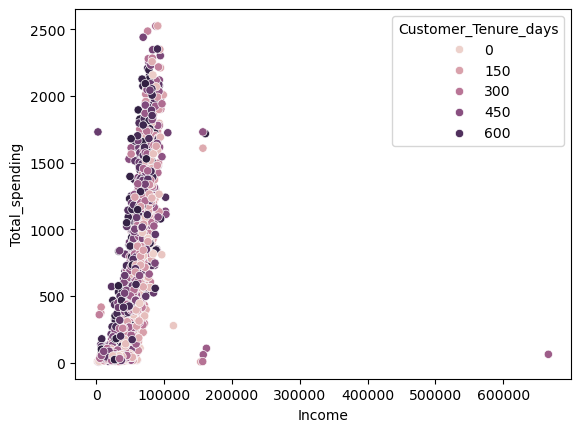

In [37]:
sns.scatterplot(x = df_clean["Income"] , y = df_clean["Total_spending"] , hue= df_clean["Customer_Tenure_days"])

# Handle Outlier

In [38]:
cols = ["Income" ,"Recency" , "Age" ,"Customer_Tenure_days" ,"Total_spending" ,"Total_kids"]

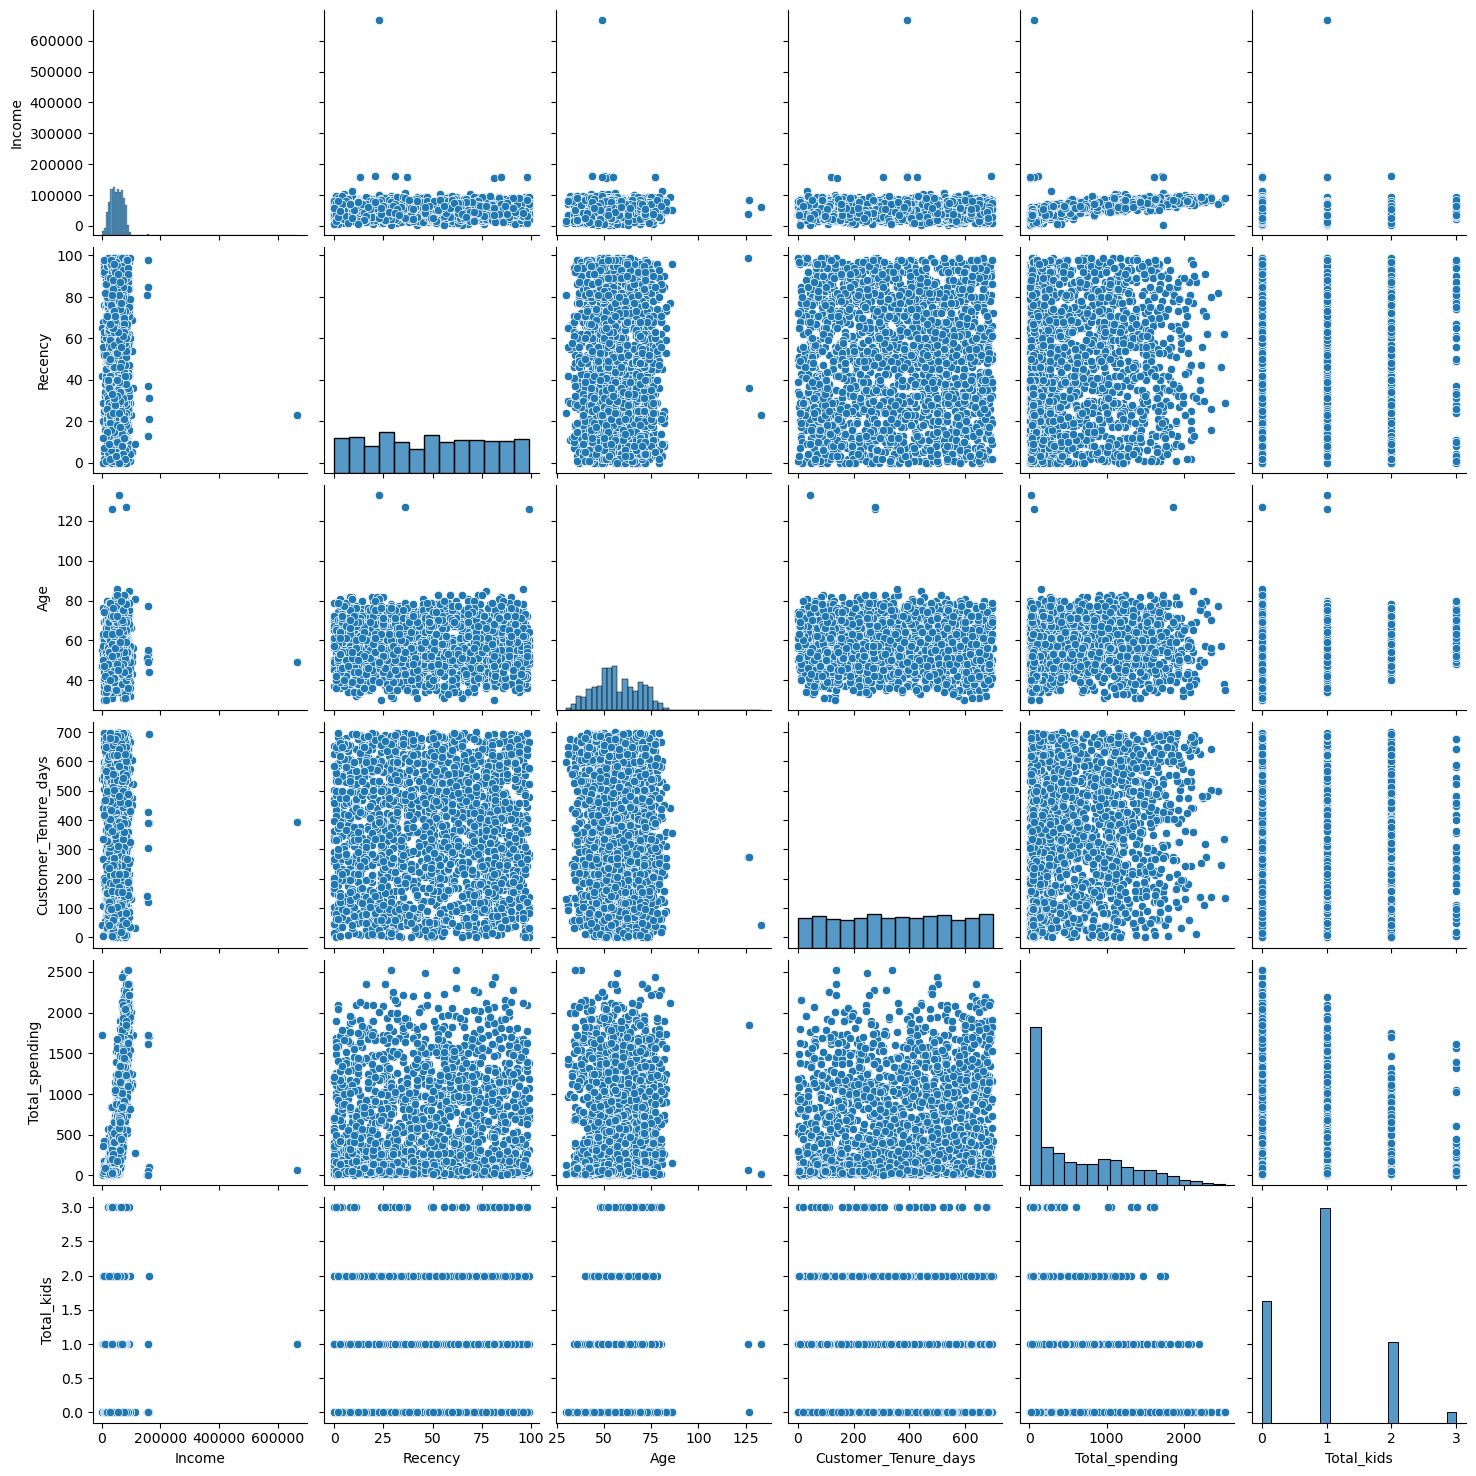

In [39]:
sns.pairplot(df_clean[cols])

In [40]:
# Remove Outlier

len(df_clean)

2240

In [41]:
df_clean = df_clean[df_clean["Age"] < 90]
df_clean = df_clean[df_clean["Income"] < 600000]

In [42]:
len(df_clean) # 4 outlier remove(3 -Age , 1- Income)

2236

In [43]:
len(df)

2240

# Coreation - Heatmap

In [44]:
num_cols = df_clean.select_dtypes(include = "number")

In [45]:
corr_matrix = num_cols.corr()

<Axes: >

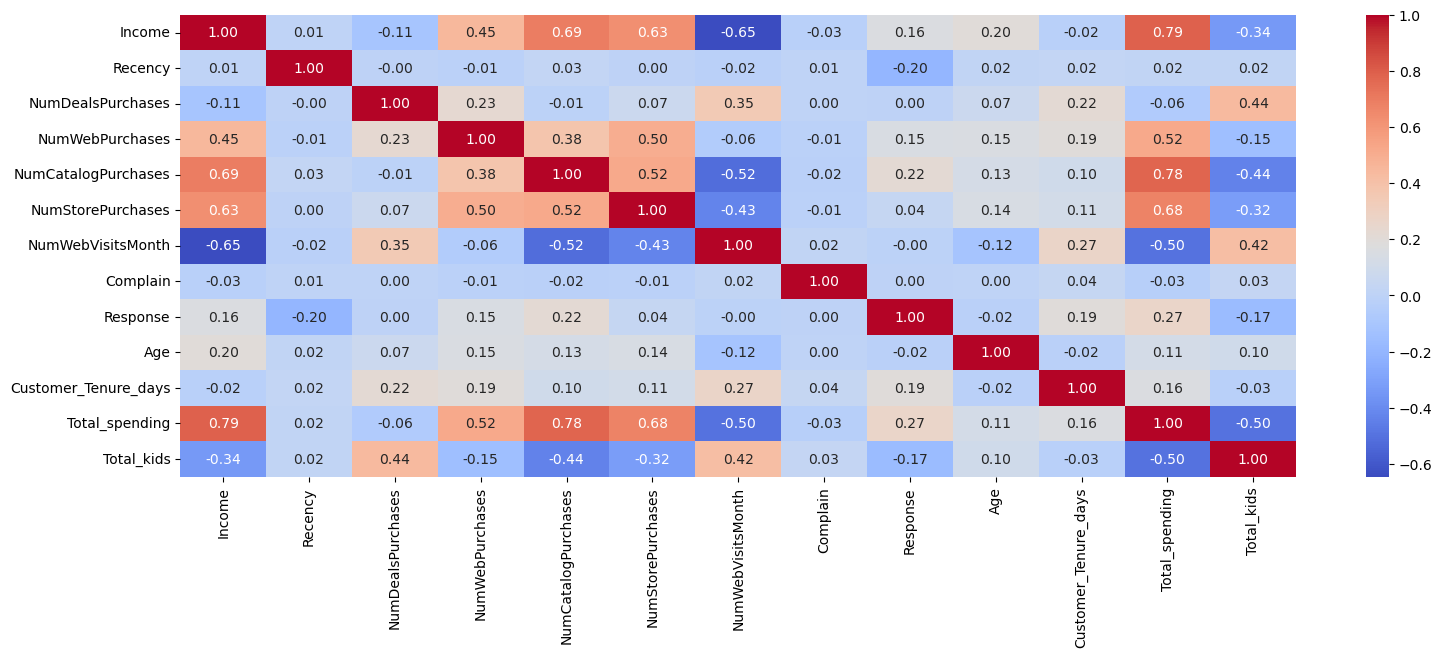

In [79]:
plt.figure(figsize =( 18, 6))

sns.heatmap(

      corr_matrix,
       annot = True,
        fmt =  ".2f",
         cmap = "coolwarm"


    
)

 # Encoding

In [47]:
from sklearn.preprocessing import OneHotEncoder

In [48]:
col = ["Education" , "Living_with"]

In [49]:
ohe = OneHotEncoder() # We dont use drop ="first" as in clustering problem each col reperesent on its own

encoder = ohe.fit_transform(df_clean[col])

In [50]:
encoder.toarray() # Imp to covert tarray

array([[1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1.]], shape=(2236, 5))

In [51]:
 ohe.get_feature_names_out(col)

array(['Education_Graduate', 'Education_PostGraduate',
       'Education_UnderGraduate', 'Living_with_Alone',
       'Living_with_Partner'], dtype=object)

In [52]:
encoder_df = pd.DataFrame(encoder.toarray() , columns = ohe.get_feature_names_out(col) , index = df_clean.index)

In [53]:
encoder_df

,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [54]:
df_clean = df_clean.drop(col , axis =1)

In [55]:
df_clean.shape

(2236, 13)

In [56]:
df_cleaned = pd.concat([df_clean ,  encoder_df] , axis =1 ) # Imp to take diff variable, df_clean - add compundly
# axis =1 , rows same columns add (13, 5) -18
# no axis , rows add(2236 + 22336) - 4472 rows with NAN value

In [57]:
df_clean.shape

(2236, 13)

In [58]:
df_cleaned

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_kids,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


## Scaling our data

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
scaler = StandardScaler()

df_scale = scaler.fit_transform(df_cleaned)

In [61]:
df_scale.shape

(2236, 18)

In [62]:
df_cleaned

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_kids,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


In [63]:
df_scale

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

## Visualization

In [64]:
from sklearn.decomposition import PCA

In [65]:
pca = PCA(n_components = 2)
df_pca = pca.fit_transform(df_scale)

Text(0, 0.5, 'PCA2')

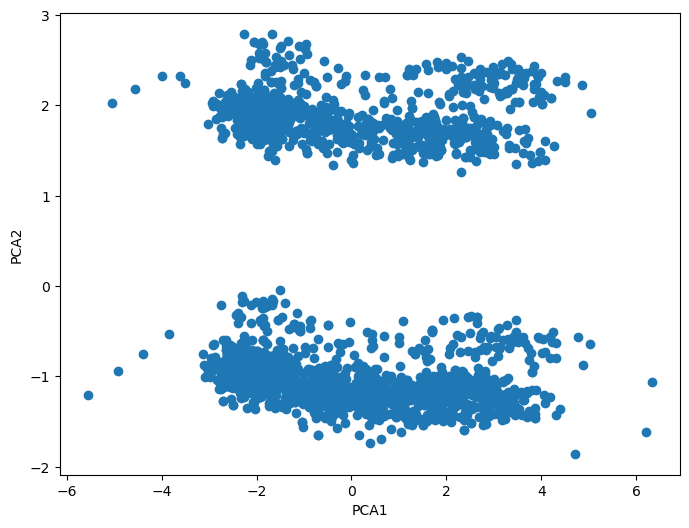

In [66]:
plt.figure(figsize = (8,6))

plt.scatter(

  x = df_pca[:,0],
  y = df_pca[:,1]
    
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")

In [67]:
df_pca

array([[ 2.7087298 ,  2.39869224],
       [-1.76655338,  1.82575242],
       [ 1.81995208, -1.07430148],
       ...,
       [ 1.42793889,  1.81716429],
       [ 1.90073104, -1.4254157 ],
       [-0.96995283, -0.67250249]], shape=(2236, 2))

In [68]:
df_pca.shape

(2236, 2)

In [69]:
df_scale.shape

(2236, 18)

In [70]:
#variance
#print(pca.explained_variance_ratio_)


In [71]:
print(pca.components_)

[[ 4.32495231e-01 -4.77962864e-06 -6.61546905e-02  2.73378035e-01
   4.09002511e-01  3.73746727e-01 -3.29131391e-01 -1.88136537e-02
   1.27218263e-01  9.66425138e-02  3.59536437e-02  4.50247045e-01
  -2.80189921e-01  7.79902112e-03  4.64731872e-02 -8.33185400e-02
   2.20964364e-02 -2.20964364e-02]
 [-3.99368915e-02 -3.14842072e-02 -4.80235286e-02 -3.11617872e-02
  -1.66793156e-02 -5.63142267e-02  3.49097435e-02  4.98712690e-03
   1.95332864e-01 -4.90583971e-02  3.66902408e-02 -8.27937537e-03
  -5.21665505e-02  5.44748637e-02 -4.65966398e-02 -1.44472010e-02
   6.85345977e-01 -6.85345977e-01]]


In [72]:
pca1 = PCA(n_components = 3)
df_pca1 = pca1.fit_transform(df_scale) 


In [73]:
pca1.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

In [74]:
df_pca1.shape

(2236, 3)

Text(0.5, 0.92, '3D Visualization')

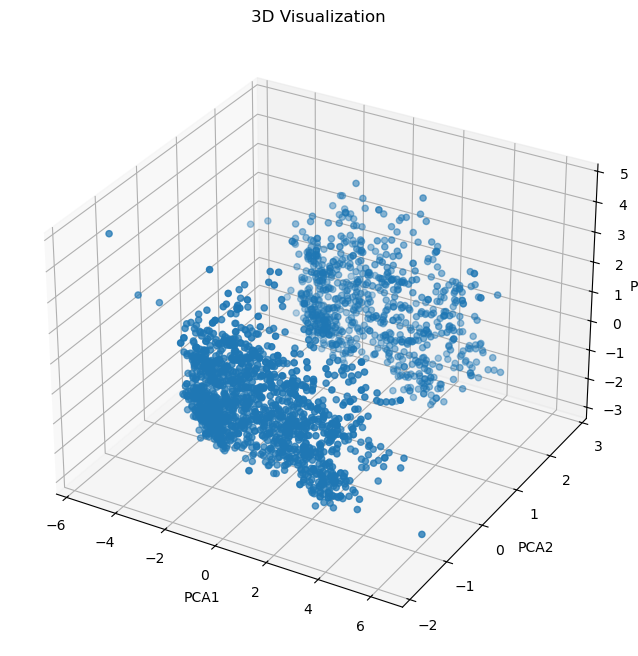

In [75]:
fig = plt.figure(figsize =(10,8))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(df_pca1[:,0] , df_pca1[:,1] , df_pca1[:,2]) 
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Visualization")

In [82]:
pca1.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

In [80]:
df_pca1.shape

(2236, 3)

In [81]:
# 5/08/2026

## Choose K value

In [106]:
wcss = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    label = kmeans.fit_predict(df_pca1)
    wcss.append(kmeans.inertia_)

In [107]:
kmeans

,n_clusters,9
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [108]:
label

array([8, 6, 1, ..., 2, 7, 4], shape=(2236,), dtype=int32)

In [109]:
wcss

[10760.84340175822,
 8830.288717243044,
 6650.969417658875,
 5006.161168001196,
 4396.308699108106,
 3857.6330644275713,
 3207.0576242216603,
 3025.2232554325824]

Text(0, 0.5, 'wcss')

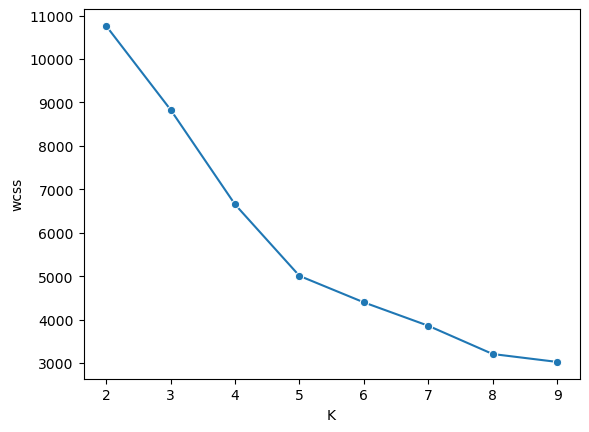

In [123]:
sns.lineplot(x = range(2,10) , y = wcss , marker = 'o')
plt.xlabel("K")
plt.ylabel("wcss")

In [113]:
from kneed import KneeLocator

kneed = KneeLocator(range(2,10) , wcss , curve = "convex"  , direction = "decreasing")

In [114]:
print(kneed.elbow)

5


## Shiloutte score

In [120]:
from sklearn.metrics import silhouette_score

ss = []

for k in range(2,10): # ss k value > 1
    kmeans = KMeans(n_clusters = k , random_state = 42)
    label = kmeans.fit_predict(df_pca1)
    score = silhouette_score(df_pca1, label)
    ss.append(score)
    

In [121]:
ss

[0.37157939079771407,
 0.30768819274758036,
 0.3580996159598421,
 0.4000152147663747,
 0.39929183898600723,
 0.4026208740563286,
 0.40508588286950054,
 0.40118897046588675]

Text(0, 0.5, 'Silhuette_score')

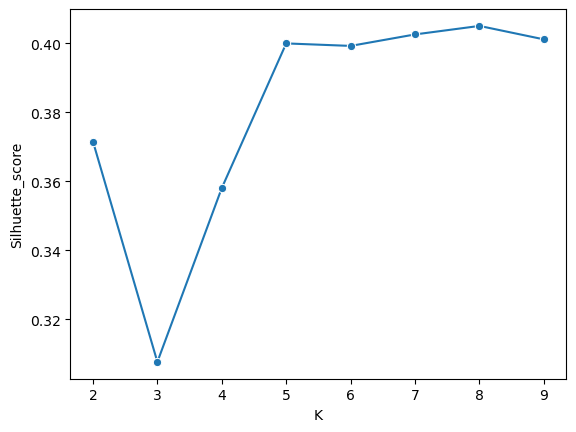

In [125]:
sns.lineplot(x = range(2,10) , y = ss , marker = 'o')
plt.xlabel("K")
plt.ylabel("Silhuette_score")

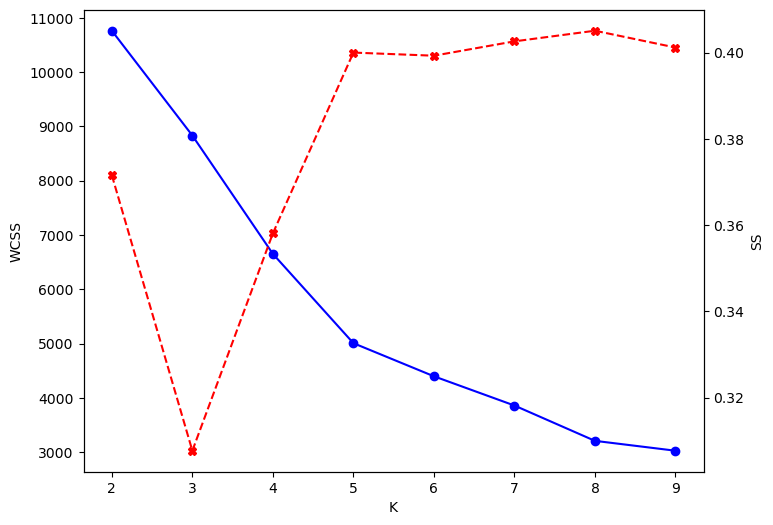

In [130]:
 ##  ss & wcss -ve co-realtion

fig , ax1 = plt.subplots(figsize = (8,6))

ax1.plot(range(2,10) , wcss, marker = "o" , color ="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.set_ylabel("SS")
ax2.plot(range(2,10) , ss , marker = "X" ,  color ="red" , linestyle ="--")

In [131]:
# Both line intercept take value of k as optimal value
#Here K =4


# K-means algo

In [134]:
kmeans = KMeans(n_clusters = 4 , random_state = 42)
kmeans

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [137]:
label = kmeans.fit_predict(df_pca1)  

In [138]:
label

array([2, 3, 2, ..., 2, 1, 1], shape=(2236,), dtype=int32)

<Axes: >

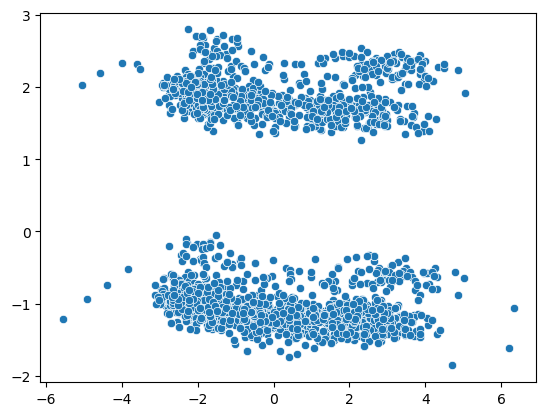

In [147]:
sns.scatterplot(x = df_pca[:,0] , y = df_pca[:,1])

In [141]:
df_pca

array([[ 2.7087298 ,  2.39869224],
       [-1.76655338,  1.82575242],
       [ 1.81995208, -1.07430148],
       ...,
       [ 1.42793889,  1.81716429],
       [ 1.90073104, -1.4254157 ],
       [-0.96995283, -0.67250249]], shape=(2236, 2))

<Axes: >

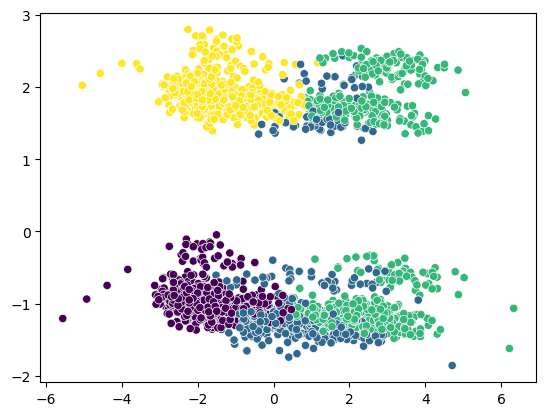

In [144]:
sns.scatterplot(x = df_pca[:,0] , y = df_pca[:,1], c = label )

Text(0.5, 0.92, '3D Visualization')

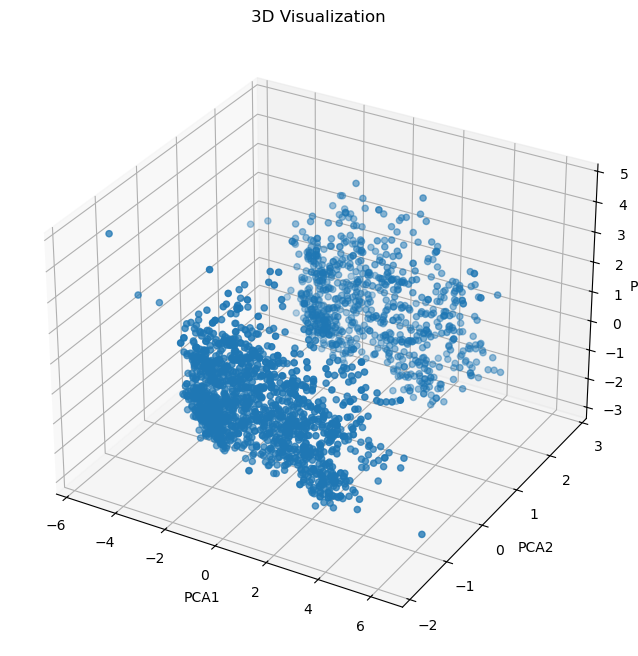

In [145]:
fig = plt.figure(figsize =(10,8))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(df_pca1[:,0] , df_pca1[:,1] , df_pca1[:,2]) 
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Visualization")

Text(0.5, 0.92, '3D Visualization')

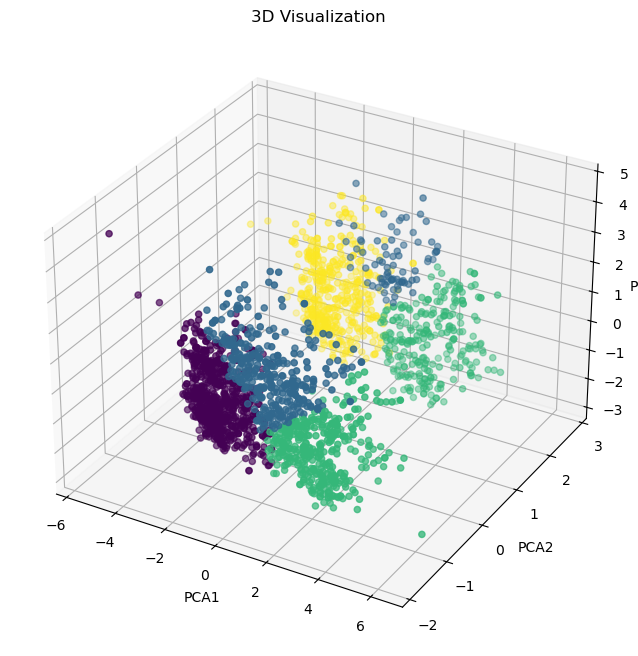

In [146]:
fig = plt.figure(figsize =(10,8))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(df_pca1[:,0] , df_pca1[:,1] , df_pca1[:,2] , c= label) 
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Visualization")

## Aglomerative

In [159]:
from sklearn.cluster import AgglomerativeClustering

aglo = AgglomerativeClustering(n_clusters = 4 , linkage = "ward")


In [160]:
aglo

,n_clusters,4
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [161]:
labels = aglo.fit_predict(df_pca1)

In [162]:
labels

array([3, 2, 1, ..., 3, 1, 0], shape=(2236,))

Text(0.5, 0.92, '3D Visualization')

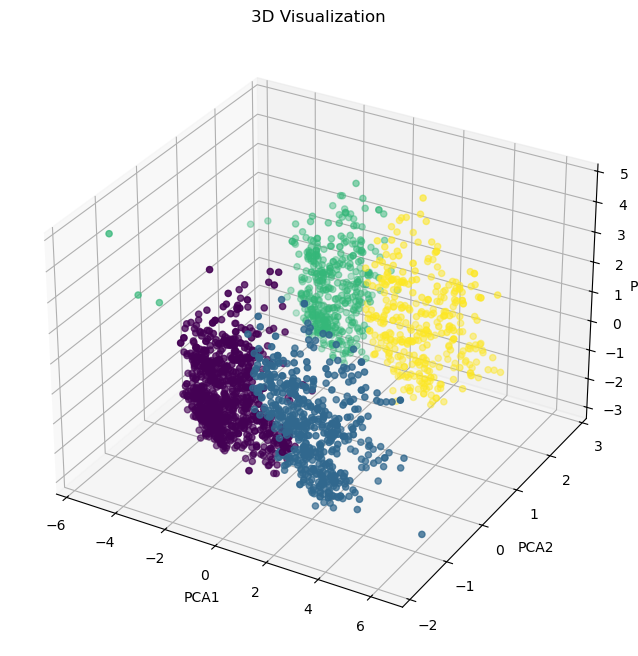

In [163]:
fig = plt.figure(figsize = (10,8))

ax = fig.add_subplot(111 , projection = "3d")

ax.scatter(df_pca1[:,0],  df_pca1[:, 1] , df_pca1[:, 2]  , c = labels)


ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Visualization")

## Characterization of clusters

In [165]:
# On the basis of Aglomerative clustering
df_cleaned

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_kids,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


In [166]:
df_cleaned["cluster"] = labels

In [167]:
df_cleaned

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_kids,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0,3
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0,1


In [168]:
pal = ["red" , "blue" , "yellow" , "green"]

<Axes: xlabel='cluster', ylabel='count'>

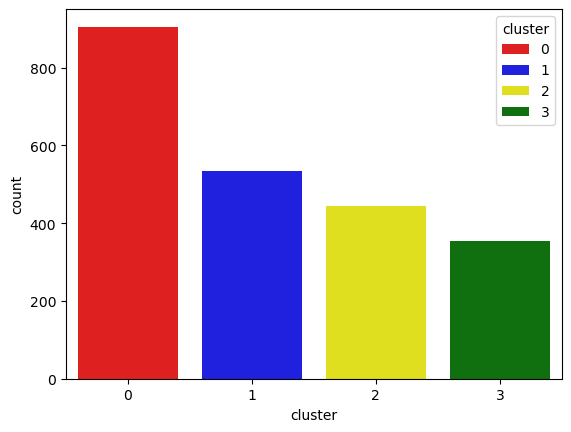

In [170]:
sns.countplot(x = df_cleaned["cluster"] , palette = pal , hue = df_cleaned["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

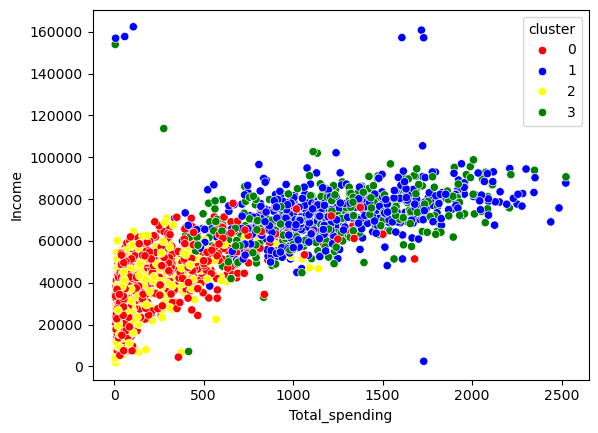

In [171]:
# Income & Total spending

sns.scatterplot(x = df_cleaned["Total_spending"] , y = df_cleaned["Income"] , hue = df_cleaned["cluster"] , palette = pal)

In [ ]:
# cluster 0(Red) - Low to Moderate Income , Low to moderate spending
# cluster 1(Blue) - High Income , High Spending
# cluster 2(Yellow) - Low Income , Low spending
# cluster 3(Green) - Moderate to High Income , High spending

<Axes: xlabel='NumCatalogPurchases', ylabel='Income'>

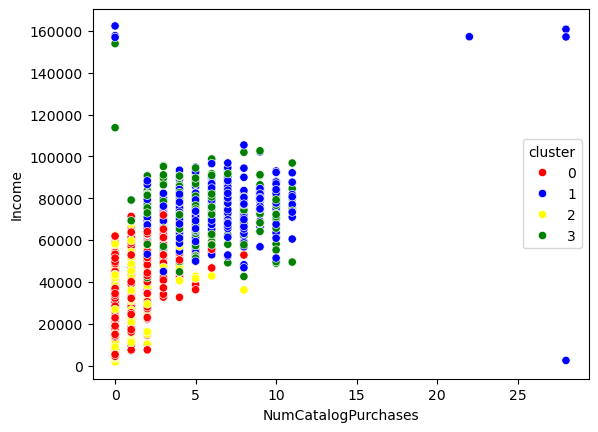

In [172]:
# Income & Catalog purchases

sns.scatterplot(x = df_cleaned["NumCatalogPurchases"] , y = df_cleaned["Income"] , hue = df_cleaned["cluster"] , palette = pal)

<Axes: xlabel='NumStorePurchases', ylabel='Income'>

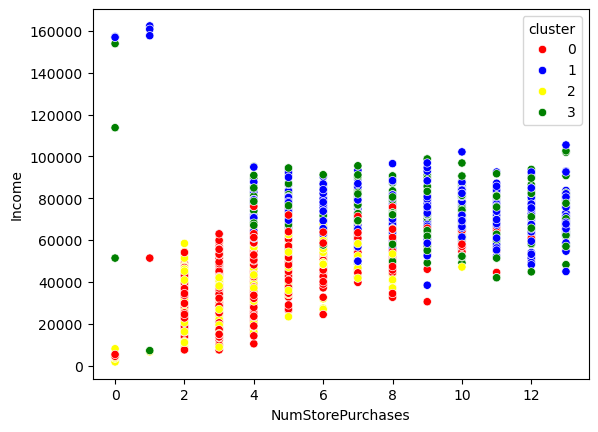

In [173]:
# Income & store purchases

sns.scatterplot(x = df_cleaned["NumStorePurchases"] , y = df_cleaned["Income"] , hue = df_cleaned["cluster"] , palette = pal)

## cluster summary for Profiling

In [177]:
cluster_sumary = df_cleaned.groupby("cluster").mean()

In [178]:
print(cluster_sumary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_days  Total_spending  \
cluster         